## Loading packages

In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import os
import sys

warnings.filterwarnings("ignore")

os.environ["R_HOME"] = "/home/bio/miniconda3/envs/spCLUE/lib/R"
# os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
# os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"
spCLUE_ROOT_PATH = "/home/bio/lhz/spatialGDC"
sys.path.append(spCLUE_ROOT_PATH)
import spCLUE

spCLUE.fix_seed(0)

## Loading data

In [2]:
sample_name="151671"
# 1. 预处理数据
adata = spCLUE.preprocess_data(input_dir="../dataset/DLPFC/151671/") 

# 🔥 关键修正：先剔除没有标签的细胞，再建图！
adata = adata[adata.obs.Region.notna()].copy() # 使用 .copy() 避免 View 警告

n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7

# 2. 现在基于过滤后的 4093 个点生成 PCA 和 图
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial")
g_expr = spCLUE.prepare_graph(adata, "expr")
graph_dict = {"spatial": g_spatia, "expr": g_expr}


[预处理开始] ---------------->
========== 路径二: 标准全基因预处理 (规范化 -> Log 转换 -> 缩放) ==========
✅ 完成规范化、Log 转换和 Z-score 缩放。

✅ 最终数据状态：
AnnData object with n_obs × n_vars = 4110 × 21631
    obs: 'in_tissue', 'array_row', 'array_col', 'Region', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'mean', 'std'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    layers: 'counts'
obs (前5行):                     in_tissue  array_row  array_col  Region  n_counts
AAACAAGTATCTCCCA-1          1         50        102  Layer5    9080.0
AAACACCAATAACTGC-1          1         59         19  Layer6    6183.0
AAACAGAGCGACTCCT-1          1         14         94  Layer3    6273.0
AAACAGCTTTCAGAAG-1          1         43          9  Layer5    7015.0
AAACAGGGTCTATATT-1          1         47         13  Layer5    6991.0
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph 

## train spCLUE

In [3]:
spCLUE_model = spCLUE.spCLUE(adata.obsm["X_pca"], graph_dict, n_clusters)
_, adata.obsm["spCLUE"] = spCLUE_model.train(
    warmup_epochs=50,   # 前 50 轮只用基础 Loss 预热特征空间
    alpha_dcd=0.1,      # 簇级对比损失 (DCDLoss) 的权重，控制空间域推远
    beta_rngpa=0.1      # 实例级对比损失 (RNGPALoss) 的权重，控制邻居拉近
)

Training Start =========================>


 20%|█████████████                                                     | 99/500 [00:59<03:59,  1.68it/s]

epoch 100: 0.46803914278377773


In [4]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


In [5]:
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151671: 0.6942922592915558


## visualization

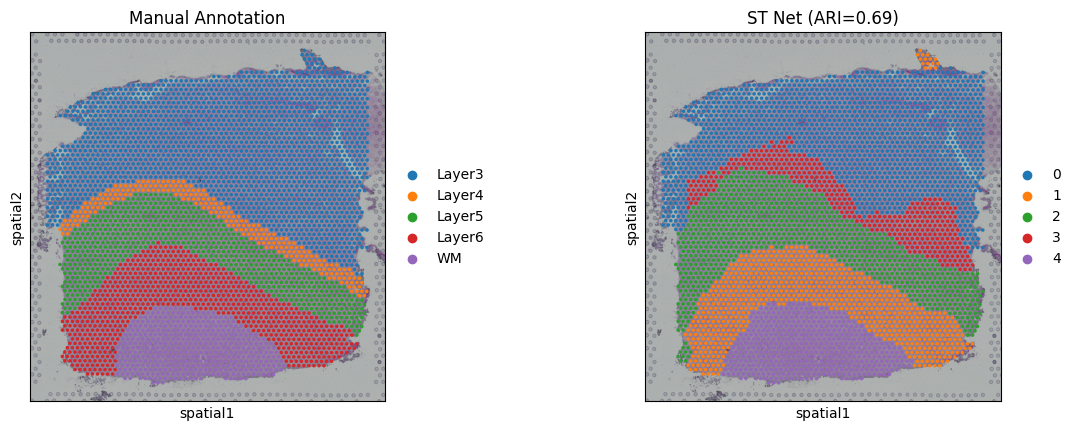

In [6]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
# sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"ST Net (ARI={round(ARI, 2)})"])
sc.pl.spatial(
    adata, 
    color=["Region", "spCLUE"], 
    title=["Manual Annotation", f"ST Net (ARI={round(ARI, 2)})"],
    show=True,        # 设置为 False，不在行间直接显示（可选）
    save="_spatial_results.png"  # 文件名后缀，Scanpy 会自动前缀 "spatial"
)

In [7]:
import itertools
import copy

# 1. 定义搜索空间 (根据之前的分析，权重建议往小了试)
search_space = {
    'alpha': [0.01, 0.1, 0.5],      # 簇级对比权重
    'beta': [0.005, 0.01, 0.05],    # 实例级对比权重 (之前0.1太高了，往调小)
    'warmup': [50, 100]             # 预热轮数
}

# 生成所有组合
keys, values = zip(*search_space.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []
best_ari = 0
best_params = None

print(f"开始网格搜索，共 {len(param_combinations)} 组配置...")

for i, params in enumerate(param_combinations):
    print(f"\n[实验 {i+1}/{len(param_combinations)}] 参数: {params}")
    
    # 重新初始化模型，保证实验独立
    test_model = spCLUE.spCLUE(adata.obsm["X_pca"], graph_dict, n_clusters)
    
    # 训练模型
    _, adata.obsm["spCLUE"] = test_model.train(
        warmup_epochs=params['warmup'], 
        alpha_dcd=params['alpha'], 
        beta_rngpa=params['beta']
    )
    
    # 执行聚类与细化
    spCLUE.clustering(
        adata,
        n_clusters,
        key="spCLUE",
        refinement=True,
        cluster_methods="mclust"
    )
    
    # 计算当前 ARI
    # 确保只计算有标签的区域
    valid_adata = adata[adata.obs.Region.notna()]
    current_ari = adjusted_rand_score(valid_adata.obs["Region"], valid_adata.obs["mclust_refined"])
    
    print(f">>> 实验 {i+1} 结束, ARI: {current_ari:.4f}")
    
    # 记录结果
    results.append({**params, 'ari': current_ari})
    
    # 更新最优配置
    if current_ari > best_ari:
        best_ari = current_ari
        best_params = params
        # 可选：保存当前最好的特征矩阵
        adata.obsm["best_spCLUE_features"] = adata.obsm["spCLUE"].copy()

print("\n" + "="*30)
print(f"网格搜索完成！")
print(f"最高 ARI: {best_ari:.4f}")
print(f"最佳参数组合: {best_params}")
print("="*30)

开始网格搜索，共 18 组配置...

[实验 1/18] 参数: {'alpha': 0.01, 'beta': 0.005, 'warmup': 50}
Training Start =========================>


 20%|█████████████                                                     | 99/500 [00:58<03:55,  1.70it/s]

epoch 100: 0.5079132585864135
fitting ...
  |                                                                      |   0%

  |======================================================================| 100%
>>> 实验 1 结束, ARI: 0.8405

[实验 2/18] 参数: {'alpha': 0.01, 'beta': 0.005, 'warmup': 100}
Training Start =========================>


 20%|████████████▊                                                    | 99/500 [00:00<00:03, 127.10it/s]

...

epoch 100: 0.45380471852737275
fitting ...
  |                                                                      |   0%

  |======================================================================| 100%
>>> 实验 17 结束, ARI: 0.5374

[实验 18/18] 参数: {'alpha': 0.5, 'beta': 0.05, 'warmup': 100}
Training Start =========================>


 20%|████████████▊                                                    | 99/500 [00:00<00:02, 134.95it/s]

epoch 100: 0.4970676456621079
fitting ...
  |                                                                      |   0%

  |======================================================================| 100%
>>> 实验 18 结束, ARI: 0.8457

网格搜索完成！
最高 ARI: 0.8539
最佳参数组合: {'alpha': 0.1, 'beta': 0.01, 'warmup': 50}
